In [1]:
import pickle
from main import Result
from src import SBsim
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
from src import SBsim_OG
import os
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Input Variables
drought_type = [87, 0.83, 2]

In [3]:
def plot_trees(ptrees):
    fig, axes = plt.subplots(1, len(ptrees), figsize=(30, 6))
    if len(ptrees) == 1:
        axes = [axes]
    
    for ax, ptree in zip(axes, ptrees):
        G = nx.DiGraph()
        pos = {}
        labels = {}
        edge_labels = {}
        
        def add_nodes_edges(node, parent=None, pos_x=0, pos_y=0, depth=1, is_left=None):
            node_id = id(node)
            pos[node_id] = (pos_x, -pos_y)
            labels[node_id] = str(node)
            G.add_node(node_id)
            
            if parent is not None:
                G.add_edge(id(parent), node_id)
                edge_labels[(id(parent), node_id)] = "True" if is_left else "False"
            
            if hasattr(node, 'l') and node.l:
                add_nodes_edges(node.l, node, pos_x - 1 / depth, pos_y + 1, depth + 1, is_left=True)
            if hasattr(node, 'r') and node.r:
                add_nodes_edges(node.r, node, pos_x + 1 / depth, pos_y + 1, depth + 1, is_left=False)
        
        add_nodes_edges(ptree.root, is_left=None)
        axes[0].set_title('Deploy Centralized')
        axes[1].set_title('Deploy Decentralized')
        axes[2].set_title('Curtailment')
        axes[3].set_title('Decommision Centralized')
        axes[4].set_title('Decommision Decentralized')
        axes[5].set_title('Decommision Curtailment')
        
        nx.draw(G, pos, with_labels=True, labels=labels, node_size=2000, node_color='lightblue', font_size=6, edge_color='gray', ax=ax)
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, ax=ax)
    
    plt.show()

In [4]:
# set optimization parameters
class OptimizationParameters(object):
    def __init__(self):
        self.cores    = 36 # this value is used only in the full scale optimization
        self.nseeds   = 1
        self.nobjs    = 1
        self.drought_type = drought_type # set drought type here [Persistence (months), Intensity (unitless), Frequency (droughts/100 years)]

#initialize action table
action = [] #Action Name
capacity = [] #Capacity (Acre-Feet/Month)
om = [] #Operation and Maintenance Costs (Million Dollars/ Acre-Feet/ Year)
cx = [] #CAPEX (Million Dollars)
lifetime = [] #Years
t_depl = [] #Time to Deployment (Month)
action_type = [] # types 1: Deploy Centralized Infrastructure, 2: Commision Decentralized Infrastructure, 3: Decommission Centralized Infrastructure, 4: Decommission Centralized Infrastructure, 5: Conservation

#Read the action table
df_actions_table = pd.read_csv("data/actions_table.csv")
action = df_actions_table['action'].values
capacity = df_actions_table['capacity (af/month)'].values
om = df_actions_table['OPEX ($10^6/af/year)'].values
cx = df_actions_table['CAPEX($10^6)'].values
t_depl = df_actions_table['time to deployment (month)'].values
lifetime = df_actions_table['lifetime (year)'].values
action_type = [int(val) for val in df_actions_table['action_type'].values]

action_name = [[], [], [], [], []]
i = 0
for act in action:
        action_name[action_type[i]].extend( [act] )
        i += 1

opt_par = OptimizationParameters()
model_sim = SBsim(opt_par, action_name, capacity, om, cx, t_depl, lifetime)

In [5]:
#file structure /home/gkittles/SB_DRIPP_Results/5_8_25_Convergence/testing_[nfe]_[mu]_[mut_prob]_[cx_prob].dat
nfe = [300000, 500000, 900000]
mu = [5,10,15]
mu_prob = [0.1, 0.5, 0.9]
cx_prob = [0.1, 0.5, 0.9]

nfe_val = []
mu_val = []
mu_prob_val = []
cx_prob_val = []
obj_list = []
log_list = []
cost_list = []
cost_convergence_list = []

m = 1
for i in range(len(nfe)):

    for j in range(len(mu)):

        for k in range(len(mu_prob)):

            for l in range(len(cx_prob)):
                if os.path.exists(f"/home/gkittles/SB_DRIPP_Results/5_8_25_Convergence/results/test_results87_0.83_1{str(nfe[i])}{str(mu[j])}{str(mu_prob[k])}{str(cx_prob[l])}.dat"):
                    open_file = open(f"/home/gkittles/SB_DRIPP_Results/5_8_25_Convergence/results/test_results87_0.83_1{str(nfe[i])}{str(mu[j])}{str(mu_prob[k])}{str(cx_prob[l])}.dat", "rb")
                    obj = pickle.load(open_file)
                    log = model_sim.simulate(obj.best_solution, 49)
                    nfe_val.append(nfe[i])
                    mu_val.append(mu[j])
                    mu_prob_val.append(mu_prob[k])
                    cx_prob_val.append(cx_prob[l])
                    obj_list.append(obj)
                    log_list.append(log)
                    cost_list.append(log.Cost)
                list = []
                with open(f"/home/gkittles/SB_DRIPP_Results/5_8_25_Convergence/slurm-64838092_{m}.out") as f:
                    for line in f:
                        ilist = [elt.strip() for elt in line.split('; ')]
                        list.append(ilist)
                cost = []
                for val in list:
                    cost.append(float(val[2].split(" ")[0]))
                cost_convergence_list.append(cost)
                m = m + 1

data = {'nfe': nfe_val, 'mu': mu_val, 'mut_prob': mu_prob_val, 'cx_prob': cx_prob_val, 'Object': obj_list, 'Log': log_list, 'Cost': cost_list, 'Cost Convergence': cost_convergence_list}
df = pd.DataFrame(data)

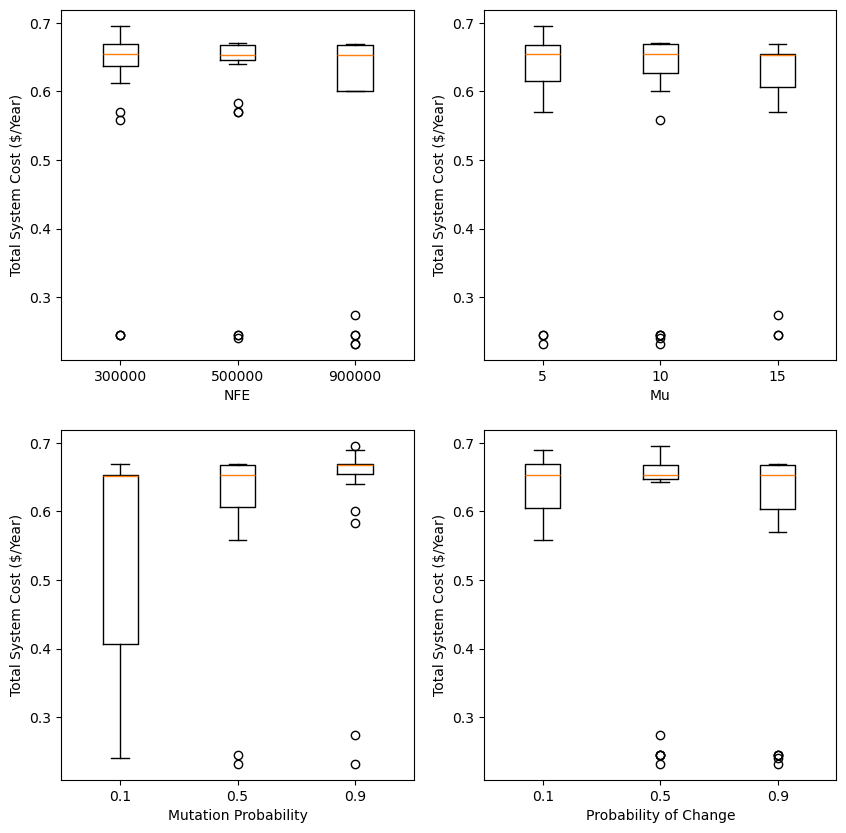

In [6]:
plt.figure(figsize=(10,10))

plt.subplot(2,2,1)
cost_nfe_3 = df[df['nfe']==300000]['Cost'].values
cost_nfe_5 = df[df['nfe']==500000]['Cost'].values
cost_nfe_9 = df[df['nfe']==900000]['Cost'].values

plt.boxplot([cost_nfe_3,cost_nfe_5,cost_nfe_9], tick_labels=['300000','500000','900000']);
plt.xlabel('NFE');
plt.ylabel('Total System Cost ($/Year)');

plt.subplot(2,2,2)
cost_mu_5 = df[df['mu']==5]['Cost'].values
cost_mu_10 = df[df['mu']==10]['Cost'].values
cost_mu_15 = df[df['mu']==15]['Cost'].values

plt.boxplot([cost_mu_5,cost_mu_10,cost_mu_15], tick_labels=['5','10','15']);
plt.xlabel('Mu');
plt.ylabel('Total System Cost ($/Year)');

plt.subplot(2,2,3)
cost_mut_1 = df[df['mut_prob']==0.1]['Cost'].values
cost_mut_5 = df[df['mut_prob']==0.5]['Cost'].values
cost_mut_9 = df[df['mut_prob']==0.9]['Cost'].values

plt.boxplot([cost_mut_1,cost_mut_5,cost_mut_9], tick_labels=['0.1','0.5','0.9']);
plt.xlabel('Mutation Probability');
plt.ylabel('Total System Cost ($/Year)');

plt.subplot(2,2,4)
cost_cx_1 = df[df['cx_prob']==0.1]['Cost'].values
cost_cx_5 = df[df['cx_prob']==0.5]['Cost'].values
cost_cx_9 = df[df['cx_prob']==0.9]['Cost'].values

plt.boxplot([cost_cx_1,cost_cx_5,cost_cx_9], tick_labels=['0.1','0.5','0.9']);
plt.xlabel('Probability of Change');
plt.ylabel('Total System Cost ($/Year)');

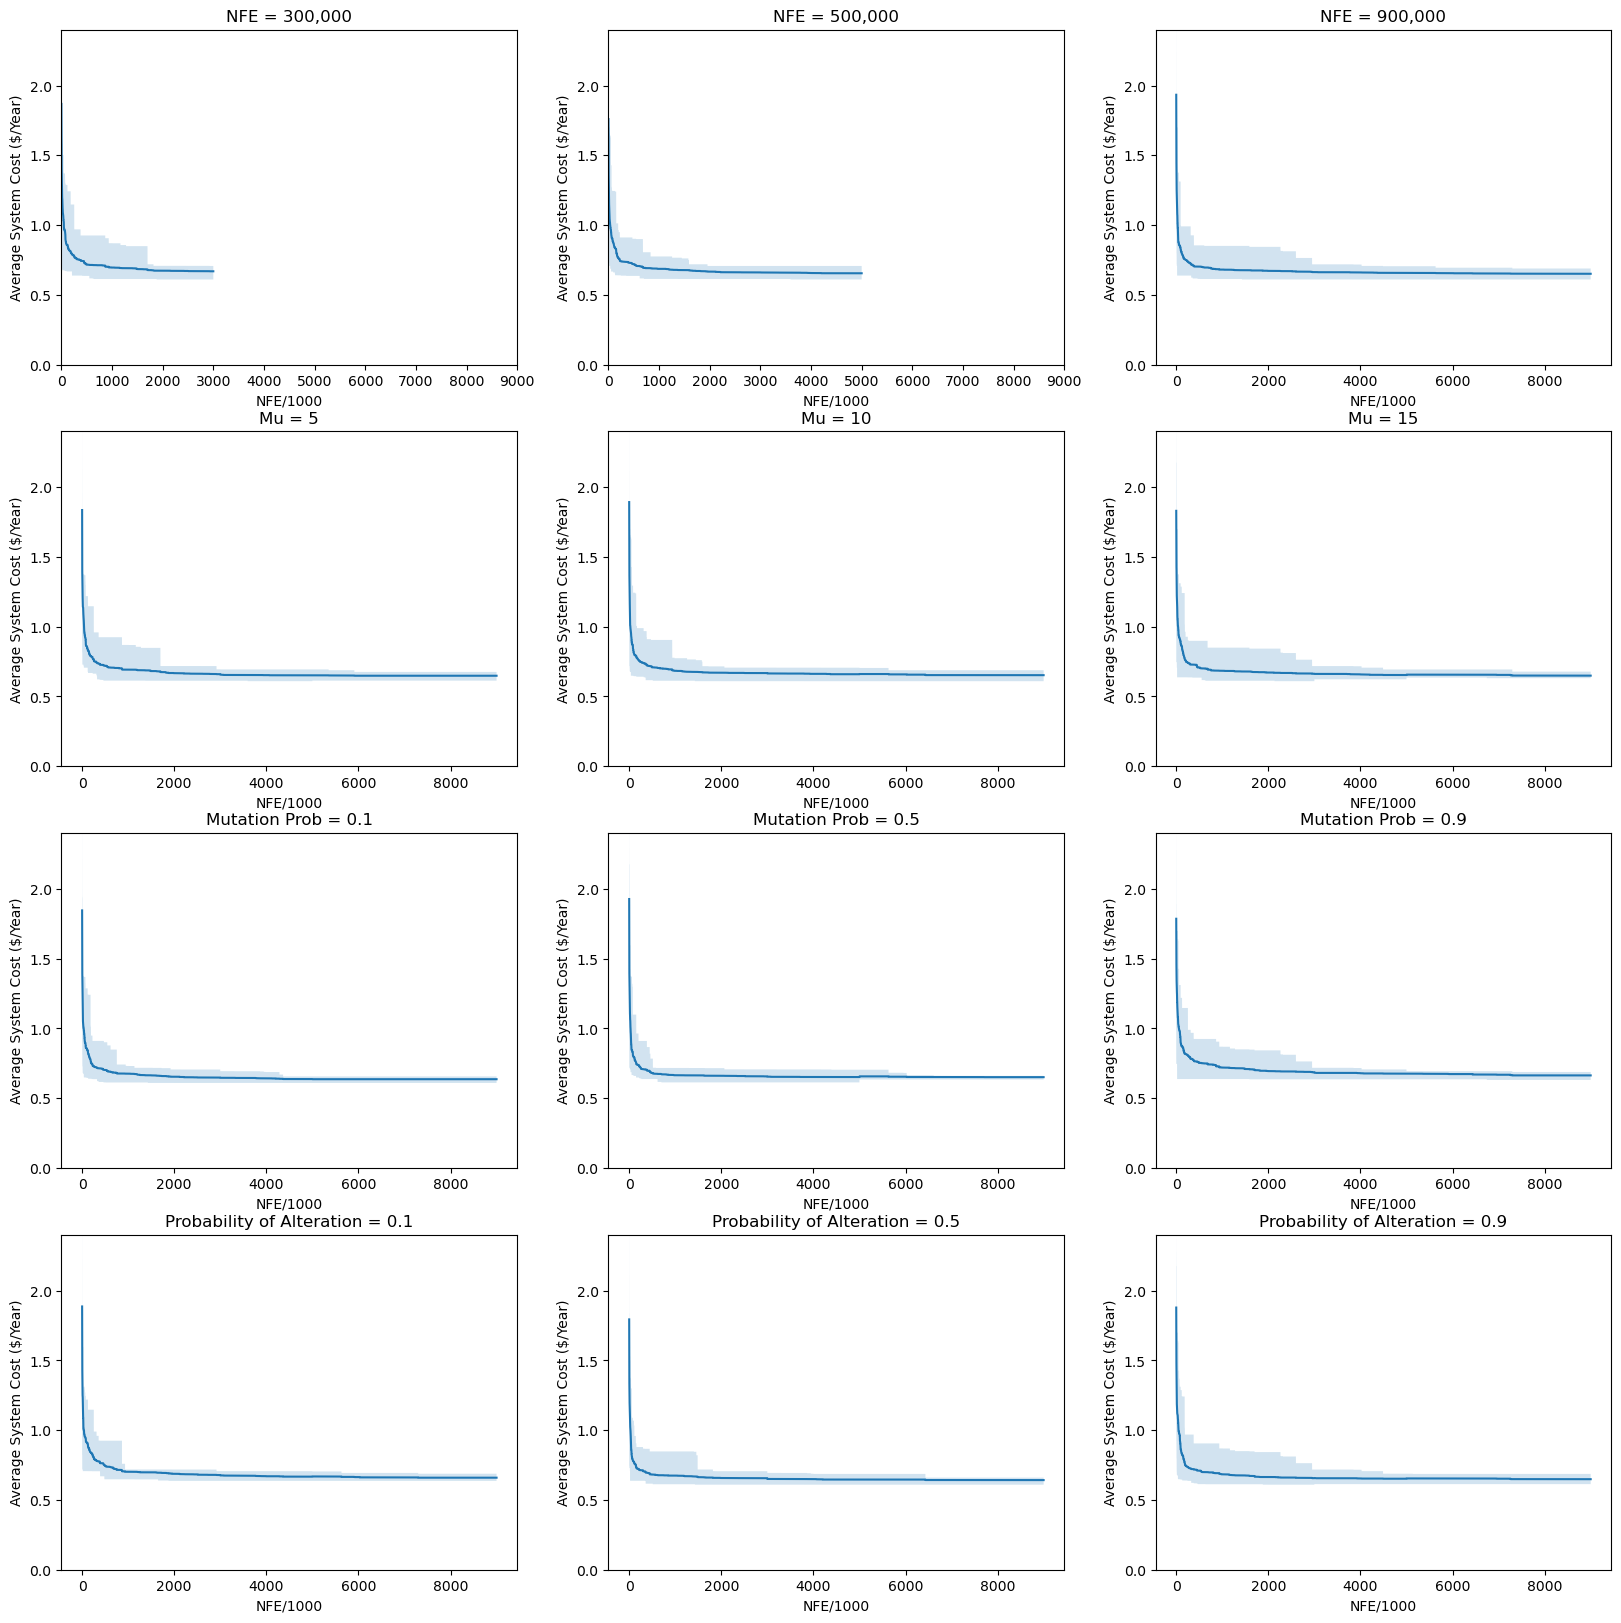

In [7]:
plt.figure(figsize = (20,20))

plt.subplot(4,3,1)
avg_cost = np.zeros(3000)
min_cost = 3*np.ones(3000)
max_cost = np.zeros(3000)
for val in df[df['nfe']==300000]['Cost Convergence'].values:
    for i in range(len(val)):
        avg_cost[i] = avg_cost[i] + val[i]
        if val[i] < min_cost[i]:
            min_cost[i] = val[i]
        if val[i] > max_cost[i]:
            max_cost[i] = val[i]
for j in range(len(avg_cost)):
    avg_cost[j] = avg_cost[j]/27
plt.fill_between(range(3000),min_cost,max_cost,alpha = 0.2)
plt.plot(avg_cost);
plt.xlim(0,9000)
plt.ylim(0,2.4);
plt.xlabel("NFE/1000");
plt.ylabel("Average System Cost ($/Year)");
plt.title("NFE = 300,000");

plt.subplot(4,3,2)
avg_cost = np.zeros(5000)
min_cost = 3*np.ones(5000)
max_cost = np.zeros(5000)
for val in df[df['nfe']==500000]['Cost Convergence'].values:
    for i in range(len(val)):
        avg_cost[i] = avg_cost[i] + val[i]
        if val[i] < min_cost[i]:
            min_cost[i] = val[i]
        if val[i] > max_cost[i]:
            max_cost[i] = val[i]
for j in range(len(avg_cost)):
    avg_cost[j] = avg_cost[j]/27
plt.fill_between(range(5000),min_cost,max_cost,alpha = 0.2)
plt.plot(avg_cost);
plt.xlim(0,9000)
plt.ylim(0,2.4);
plt.xlabel("NFE/1000");
plt.ylabel("Average System Cost ($/Year)");
plt.title("NFE = 500,000");

plt.subplot(4,3,3)
avg_cost = np.zeros(9000)
min_cost = 3*np.ones(9000)
max_cost = np.zeros(9000)
for val in df[df['nfe']==900000]['Cost Convergence'].values:
    for i in range(len(val)):
        avg_cost[i] = avg_cost[i] + val[i]
        if val[i] < min_cost[i]:
            min_cost[i] = val[i]
        if val[i] > max_cost[i]:
            max_cost[i] = val[i]
for j in range(len(avg_cost)):
    avg_cost[j] = avg_cost[j]/27
plt.fill_between(range(9000),min_cost,max_cost,alpha = 0.2)
plt.plot(avg_cost);
plt.ylim(0,2.4);
plt.xlabel("NFE/1000");
plt.ylabel("Average System Cost ($/Year)");
plt.title("NFE = 900,000");

plt.subplot(4,3,4)
avg_cost = np.zeros(9000)
min_cost = 3*np.ones(9000)
max_cost = np.zeros(9000)
for val in df[df['mu']==5]['Cost Convergence'].values:
    for i in range(len(val)):
        avg_cost[i] = avg_cost[i] + val[i]
        if val[i] < min_cost[i]:
            min_cost[i] = val[i]
        if val[i] > max_cost[i]:
            max_cost[i] = val[i]
for j in range(len(avg_cost)):
    if j < 3000:
        avg_cost[j] = avg_cost[j]/27
    elif j < 5000:
        avg_cost[j] = avg_cost[j]/18
    else:
        avg_cost[j] = avg_cost[j]/9
plt.fill_between(range(9000),min_cost,max_cost,alpha = 0.2)
plt.plot(avg_cost);
plt.xlabel("NFE/1000");
plt.ylim(0,2.4);
plt.ylabel("Average System Cost ($/Year)");
plt.title("Mu = 5");

plt.subplot(4,3,5)
avg_cost = np.zeros(9000)
min_cost = 3*np.ones(9000)
max_cost = np.zeros(9000)
for val in df[df['mu']==10]['Cost Convergence'].values:
    for i in range(len(val)):
        avg_cost[i] = avg_cost[i] + val[i]
        if val[i] < min_cost[i]:
            min_cost[i] = val[i]
        if val[i] > max_cost[i]:
            max_cost[i] = val[i]
for j in range(len(avg_cost)):
    if j < 3000:
        avg_cost[j] = avg_cost[j]/27
    elif j < 5000:
        avg_cost[j] = avg_cost[j]/18
    else:
        avg_cost[j] = avg_cost[j]/9
plt.fill_between(range(9000),min_cost,max_cost,alpha = 0.2)
plt.plot(avg_cost);
plt.ylim(0,2.4);
plt.xlabel("NFE/1000");
plt.ylabel("Average System Cost ($/Year)");
plt.title("Mu = 10");

plt.subplot(4,3,6)
avg_cost = np.zeros(9000)
min_cost = 3*np.ones(9000)
max_cost = np.zeros(9000)
for val in df[df['mu']==15]['Cost Convergence'].values:
    for i in range(len(val)):
        avg_cost[i] = avg_cost[i] + val[i]
        if val[i] < min_cost[i]:
            min_cost[i] = val[i]
        if val[i] > max_cost[i]:
            max_cost[i] = val[i]
for j in range(len(avg_cost)):
    if j < 3000:
        avg_cost[j] = avg_cost[j]/27
    elif j < 5000:
        avg_cost[j] = avg_cost[j]/18
    else:
        avg_cost[j] = avg_cost[j]/9
plt.fill_between(range(9000),min_cost,max_cost,alpha = 0.2)
plt.plot(avg_cost);
plt.ylim(0,2.4);
plt.xlabel("NFE/1000");
plt.ylabel("Average System Cost ($/Year)");
plt.title("Mu = 15");

plt.subplot(4,3,7)
avg_cost = np.zeros(9000)
min_cost = 3*np.ones(9000)
max_cost = np.zeros(9000)
for val in df[df['mut_prob']==0.1]['Cost Convergence'].values:
    for i in range(len(val)):
        avg_cost[i] = avg_cost[i] + val[i]
        if val[i] < min_cost[i]:
            min_cost[i] = val[i]
        if val[i] > max_cost[i]:
            max_cost[i] = val[i]
for j in range(len(avg_cost)):
    if j < 3000:
        avg_cost[j] = avg_cost[j]/27
    elif j < 5000:
        avg_cost[j] = avg_cost[j]/18
    else:
        avg_cost[j] = avg_cost[j]/9
plt.fill_between(range(9000),min_cost,max_cost,alpha = 0.2)
plt.plot(avg_cost);
plt.ylim(0,2.4);
plt.xlabel("NFE/1000");
plt.ylabel("Average System Cost ($/Year)");
plt.title("Mutation Prob = 0.1");

plt.subplot(4,3,8)
avg_cost = np.zeros(9000)
min_cost = 3*np.ones(9000)
max_cost = np.zeros(9000)
for val in df[df['mut_prob']==0.5]['Cost Convergence'].values:
    for i in range(len(val)):
        avg_cost[i] = avg_cost[i] + val[i]
        if val[i] < min_cost[i]:
            min_cost[i] = val[i]
        if val[i] > max_cost[i]:
            max_cost[i] = val[i]
for j in range(len(avg_cost)):
    if j < 3000:
        avg_cost[j] = avg_cost[j]/27
    elif j < 5000:
        avg_cost[j] = avg_cost[j]/18
    else:
        avg_cost[j] = avg_cost[j]/9
plt.fill_between(range(9000),min_cost,max_cost,alpha = 0.2)
plt.plot(avg_cost);
plt.ylim(0,2.4);
plt.xlabel("NFE/1000");
plt.ylabel("Average System Cost ($/Year)");
plt.title("Mutation Prob = 0.5");

plt.subplot(4,3,9)
avg_cost = np.zeros(9000)
min_cost = 3*np.ones(9000)
max_cost = np.zeros(9000)
for val in df[df['mut_prob']==0.9]['Cost Convergence'].values:
    for i in range(len(val)):
        avg_cost[i] = avg_cost[i] + val[i]
        if val[i] < min_cost[i]:
            min_cost[i] = val[i]
        if val[i] > max_cost[i]:
            max_cost[i] = val[i]
for j in range(len(avg_cost)):
    if j < 3000:
        avg_cost[j] = avg_cost[j]/27
    elif j < 5000:
        avg_cost[j] = avg_cost[j]/18
    else:
        avg_cost[j] = avg_cost[j]/9
plt.fill_between(range(9000),min_cost,max_cost,alpha = 0.2)
plt.plot(avg_cost);
plt.ylim(0,2.4);
plt.xlabel("NFE/1000");
plt.ylabel("Average System Cost ($/Year)");
plt.title("Mutation Prob = 0.9");

plt.subplot(4,3,10)
avg_cost = np.zeros(9000)
min_cost = 3*np.ones(9000)
max_cost = np.zeros(9000)
for val in df[df['cx_prob']==0.1]['Cost Convergence'].values:
    for i in range(len(val)):
        avg_cost[i] = avg_cost[i] + val[i]
        if val[i] < min_cost[i]:
            min_cost[i] = val[i]
        if val[i] > max_cost[i]:
            max_cost[i] = val[i]
for j in range(len(avg_cost)):
    if j < 3000:
        avg_cost[j] = avg_cost[j]/27
    elif j < 5000:
        avg_cost[j] = avg_cost[j]/18
    else:
        avg_cost[j] = avg_cost[j]/9
plt.fill_between(range(9000),min_cost,max_cost,alpha = 0.2)
plt.plot(avg_cost);
plt.ylim(0,2.4);
plt.xlabel("NFE/1000");
plt.ylabel("Average System Cost ($/Year)");
plt.title("Probability of Alteration = 0.1");

plt.subplot(4,3,11)
avg_cost = np.zeros(9000)
min_cost = 3*np.ones(9000)
max_cost = np.zeros(9000)
for val in df[df['cx_prob']==0.5]['Cost Convergence'].values:
    for i in range(len(val)):
        avg_cost[i] = avg_cost[i] + val[i]
        if val[i] < min_cost[i]:
            min_cost[i] = val[i]
        if val[i] > max_cost[i]:
            max_cost[i] = val[i]
for j in range(len(avg_cost)):
    if j < 3000:
        avg_cost[j] = avg_cost[j]/27
    elif j < 5000:
        avg_cost[j] = avg_cost[j]/18
    else:
        avg_cost[j] = avg_cost[j]/9
plt.fill_between(range(9000),min_cost,max_cost,alpha = 0.2)
plt.plot(avg_cost);
plt.ylim(0,2.4);
plt.xlabel("NFE/1000");
plt.ylabel("Average System Cost ($/Year)");
plt.title("Probability of Alteration = 0.5");

plt.subplot(4,3,12)
avg_cost = np.zeros(9000)
min_cost = 3*np.ones(9000)
max_cost = np.zeros(9000)
for val in df[df['cx_prob']==0.9]['Cost Convergence'].values:
    for i in range(len(val)):
        avg_cost[i] = avg_cost[i] + val[i]
        if val[i] < min_cost[i]:
            min_cost[i] = val[i]
        if val[i] > max_cost[i]:
            max_cost[i] = val[i]
for j in range(len(avg_cost)):
    if j < 3000:
        avg_cost[j] = avg_cost[j]/27
    elif j < 5000:
        avg_cost[j] = avg_cost[j]/18
    else:
        avg_cost[j] = avg_cost[j]/9
plt.fill_between(range(9000),min_cost,max_cost,alpha = 0.2)
plt.plot(avg_cost);
plt.ylim(0,2.4);
plt.xlabel("NFE/1000");
plt.ylabel("Average System Cost ($/Year)");
plt.title("Probability of Alteration = 0.9");

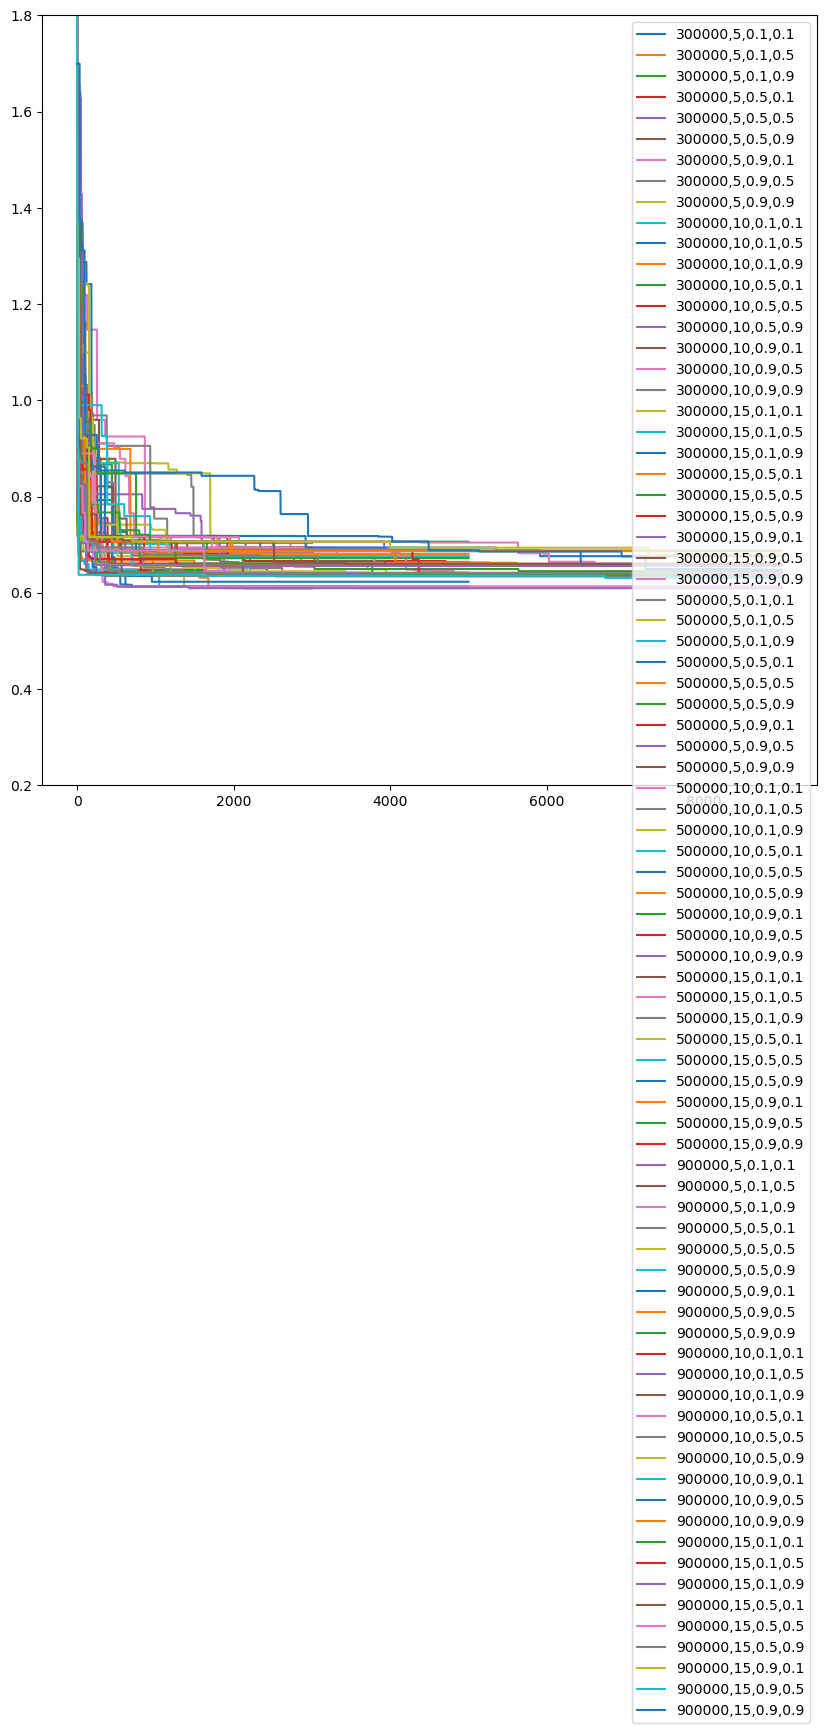

In [8]:
vals = df['Cost Convergence'].values
x = df['nfe'].values
l1 = df['mu'].values
l2 = df['mut_prob'].values
l3 = df['cx_prob'].values

plt.figure(figsize=(10,10))
for i in range(int(len(x))):
    #if all([l1[i] == 5]):
    plt.plot(range(int(x[i]/100)),vals[i], label=f"{x[i]},{l1[i]},{l2[i]},{l3[i]}");
plt.legend();
#plt.xlim(0,5000);
plt.ylim(0.2,1.8);

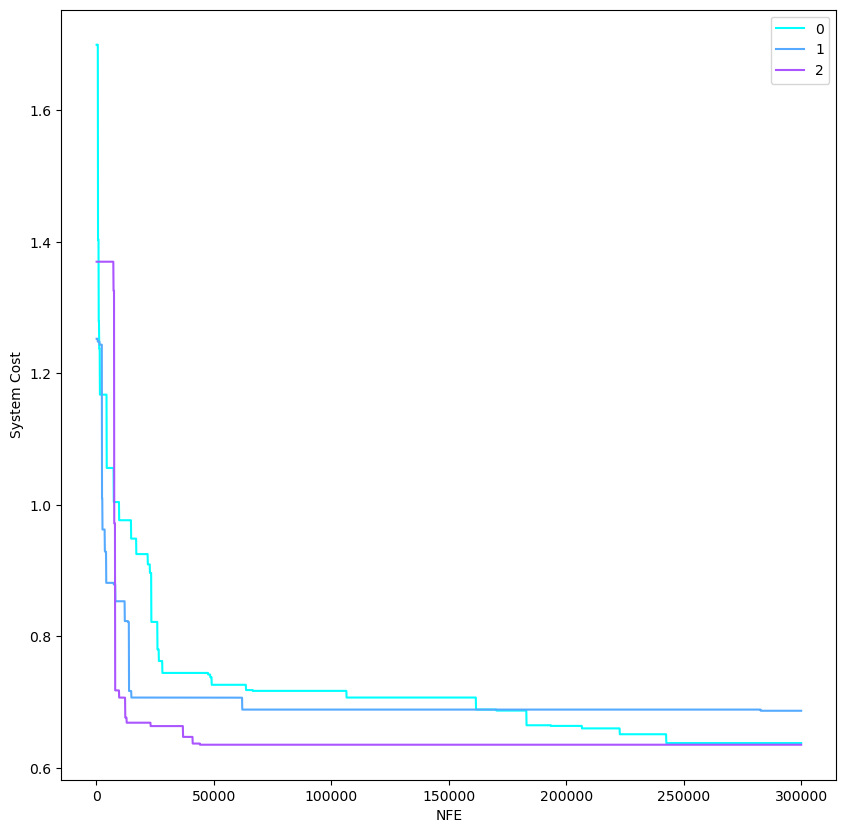

In [9]:
plt.figure(figsize=(10,10))
list_fail = []
final_cost = []
for i in range(3):
    if i in list_fail:
        continue
    list = []
    with open(f"/home/gkittles/SB_DRIPP_Results/5_8_25_Convergence/slurm-64838092_{i+1}.out") as f:
        for line in f:
            ilist = [elt.strip() for elt in line.split('; ')]
            list.append(ilist)
    nfe = []
    cost = []
    for val in list:
        nfe.append(int(val[0].split(" ")[1]))
        cost.append(float(val[2].split(" ")[0]))
    color = plt.cm.cool(i/3)
    plt.plot(nfe,cost, label = f"{i}", color=color);
    final_cost.append(cost[-1])
plt.legend();
plt.xlabel('NFE');
plt.ylabel('System Cost');

In [14]:
min_c = 10000000
min_i = 0
j = 0
final_costs = []
for costs in df['Cost Convergence'].values:
    final_costs.append(costs[-1])
    if costs[-1] < min_c:
        min_c = costs[-1]
        min_i = j
    j = j + 1

print(min_i)

sorted_index = sorted(range(len(final_costs)), key=lambda k:final_costs[k])

11


300000
10
0.1
0.9


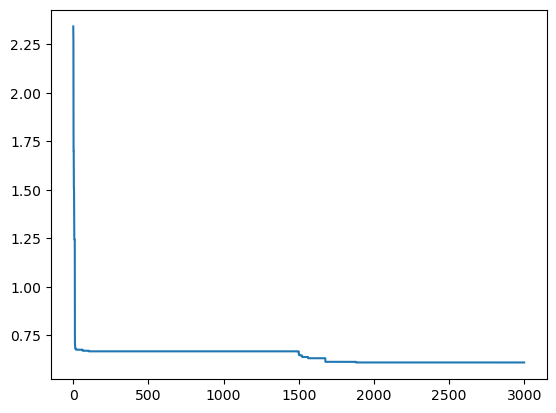

In [12]:
plt.plot(df['Cost Convergence'].values[11]);
print(df['nfe'].values[11])
print(df['mu'].values[11])
print(df['mut_prob'].values[11])
print(df['cx_prob'].values[11])

300000
5
0.1
0.9


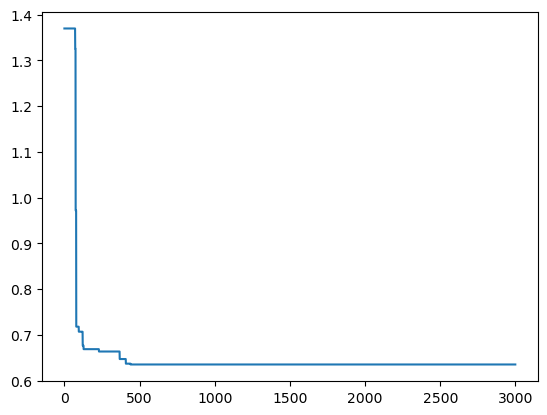

In [24]:
k = 10
plt.plot(df['Cost Convergence'].values[sorted_index[k]]);
print(df['nfe'].values[sorted_index[k]])
print(df['mu'].values[sorted_index[k]])
print(df['mut_prob'].values[sorted_index[k]])
print(df['cx_prob'].values[sorted_index[k]])

In [25]:
min_c = 10000000
min_i = 0
j = 0
final_costs = []
for costs in df['Cost Convergence'].values:
    final_costs.append(costs[2999])
    if costs[-1] < min_c:
        min_c = costs[2999]
        min_i = j
    j = j + 1

print(min_i)

sorted_index = sorted(range(len(final_costs)), key=lambda k:final_costs[k])

11


300000
10
0.1
0.9


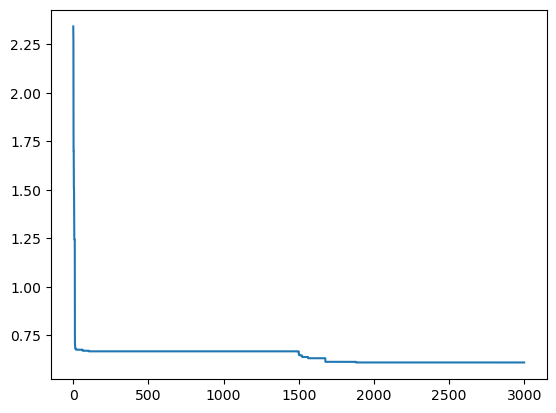

In [41]:
k = 0
plt.plot(df['Cost Convergence'].values[sorted_index[k]]);
print(df['nfe'].values[sorted_index[k]])
print(df['mu'].values[sorted_index[k]])
print(df['mut_prob'].values[sorted_index[k]])
print(df['cx_prob'].values[sorted_index[k]])